# Time Series Analysis — Final Project
## Monthly Beer Production in Australia (1956–1995)

**Dataset:** `Dataset_4__monthly-beer-production-in-austr.csv`
**Goal:** Perform a complete time series analysis: exploratory analysis, smoothing, decomposition,
residual white-noise testing, ARIMA/SARIMA modeling, diagnostics, forecasting, and model evaluation.

Every step below includes the code **and** a written interpretation of what we observe and why we
made each modeling decision, as required by the project brief.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss, acf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.gofplots import qqplot

from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.max_rows", 10)

---
## 1. Data Preparation

We start by loading the raw CSV and checking:
- data types and the shape of the dataset,
- whether the time index has duplicates, missing timestamps, or is out of order,
- missing observations,
- any obvious data-quality issues,
- whether a transformation (e.g. log) is needed.

In [2]:
df = pd.read_csv("/mnt/user-data/uploads/Dataset_4__monthly-beer-production-in-austr.csv")
df.columns = ["Month", "Production"]
print(df.shape)
df.head()

(476, 2)


,Month,Production
0,1956-01,93.2
1,1956-02,96.0
2,1956-03,95.2
3,1956-04,77.1
4,1956-05,70.9


In [3]:
# Parse the Month column as a proper monthly datetime index
df["Month"] = pd.to_datetime(df["Month"], format="%Y-%m")
df = df.sort_values("Month").reset_index(drop=True)
df = df.set_index("Month")
df.index.freq = "MS"  # explicitly set Month-Start frequency

print("Date range:", df.index.min(), "->", df.index.max())
print("Number of observations:", len(df))
print("Expected number of months if perfectly regular:",
      (df.index.max().to_period('M') - df.index.min().to_period('M')).n + 1)

Date range: 1956-01-01 00:00:00 -> 1995-08-01 00:00:00
Number of observations: 476
Expected number of months if perfectly regular: 476


**Duplicate / missing timestamp check.** We reconstruct the expected complete monthly
date range and compare it against the actual index. Any mismatch would reveal missing or
duplicated months.

In [4]:
full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq="MS")
missing_months = full_range.difference(df.index)
duplicate_months = df.index[df.index.duplicated()]

print("Missing months:", list(missing_months))
print("Duplicate months:", list(duplicate_months))
print("Missing values in 'Production':", df['Production'].isna().sum())

Missing months: []
Duplicate months: []
Missing values in 'Production': 0


**Observation:** The dataset is a clean, regularly-spaced monthly series with **no missing
timestamps, no duplicate months, and no missing values**. The data is already in chronological
order (we sorted it explicitly as a safety step regardless). No imputation is required.

**Data-quality check.** We inspect basic descriptive statistics and look for implausible values
(negative production, extreme outliers, obvious sensor/entry errors).

In [5]:
df["Production"].describe()

count    476.000000
mean     136.395378
std       33.738725
min       64.800000
25%      112.900000
50%      139.150000
75%      158.825000
max      217.800000
Name: Production, dtype: float64

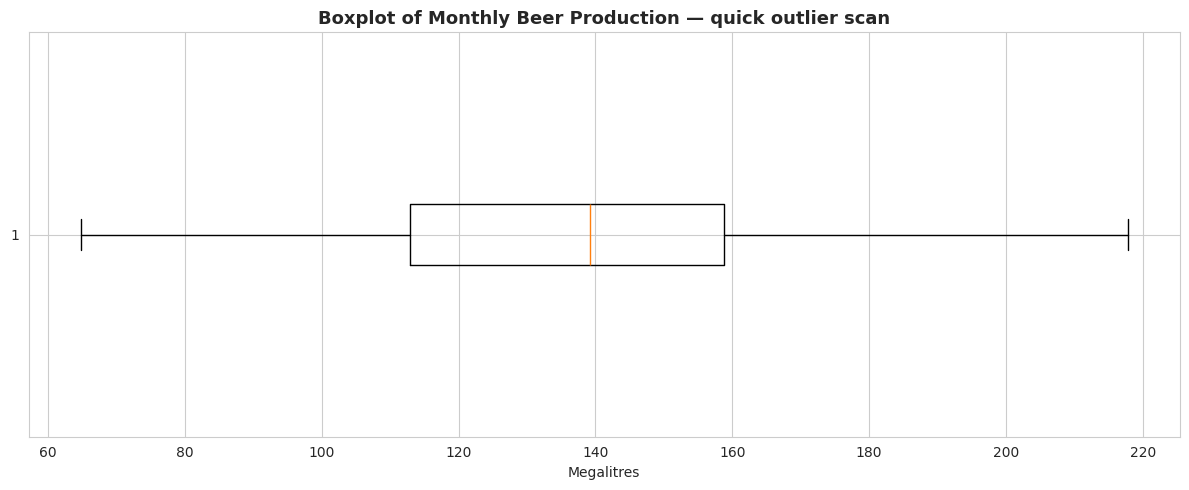

In [6]:
fig, ax = plt.subplots()
ax.boxplot(df["Production"], vert=False)
ax.set_title("Boxplot of Monthly Beer Production — quick outlier scan")
ax.set_xlabel("Megalitres")
plt.tight_layout()
plt.show()

**Observation:** All values are positive and fall in a plausible range (roughly 60–190
megalitres) with no negative or absurd values. The boxplot shows a small number of high points
on the upper tail, but these coincide with known seasonal (holiday-season) peaks rather than data
errors, so we keep them.

**Transformation.** We will only decide on a log-transform after we look at the plot and check
whether the seasonal amplitude grows with the level (which would call for a multiplicative model /
log transform). This is examined in Sections 2 and 4.

The dataset is now clean and ready for exploratory analysis.

---
## 2. Exploratory Time Series Analysis

We plot the raw series, look for trend/seasonality/noise, compute rolling statistics, and
examine the ACF/PACF to get a first read on temporal dependence.

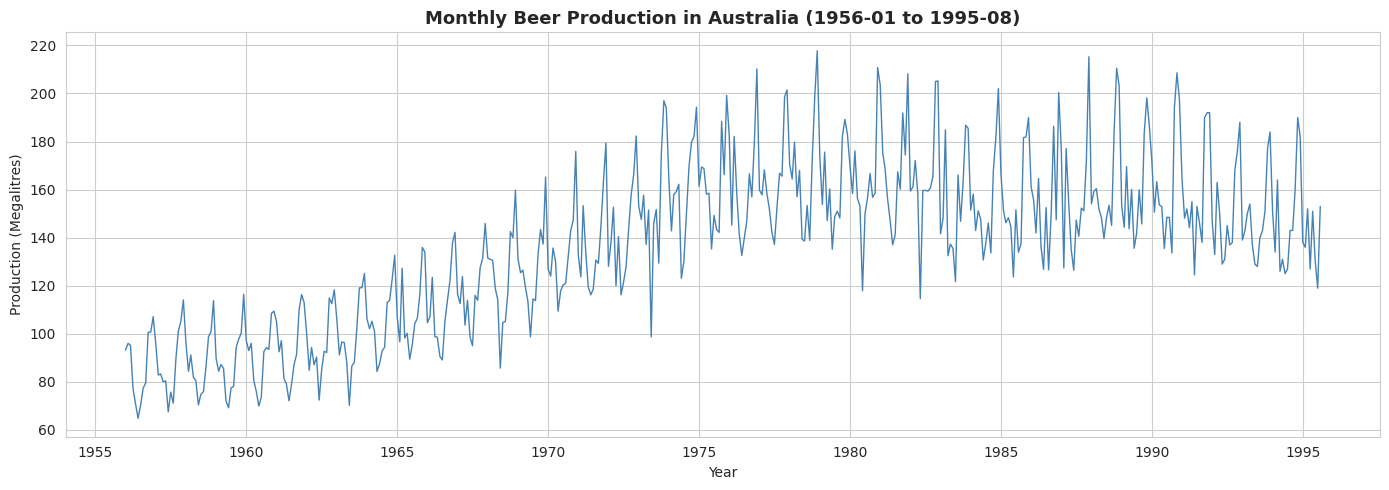

In [7]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df["Production"], color="steelblue", linewidth=1)
ax.set_title("Monthly Beer Production in Australia (1956-01 to 1995-08)")
ax.set_xlabel("Year")
ax.set_ylabel("Production (Megalitres)")
plt.tight_layout()
plt.show()

**Observation on the raw plot:**
- There is a clear **upward trend** from 1956 into the mid-1970s/1980s, followed by a **flattening
and a slight decline / stabilization** from the mid-1980s to 1995. So the trend is not simply
linear over the whole span — it is closer to a slowly-varying, non-linear trend.
- There is a strong, regular **annual seasonal pattern** (12-month cycle) — production rises
towards the end of each year (Australian summer, more beer consumption) and dips mid-year.
- The **amplitude of the seasonal swings appears to grow somewhat as the level of the series
grows** in the earlier decades, which is a hint that a multiplicative (or log-additive) structure
may fit better than a purely additive one — we test this formally in Section 4.
- There does not appear to be an obvious structural break, but the variance in the last ~10 years
looks slightly more stable than earlier — consistent with maturing production capacity.

**Rolling statistics.** A rolling mean smooths out the seasonal fluctuations and highlights the
underlying trend; a rolling standard deviation checks whether the variance of the series is
roughly constant (stationarity clue) or growing.

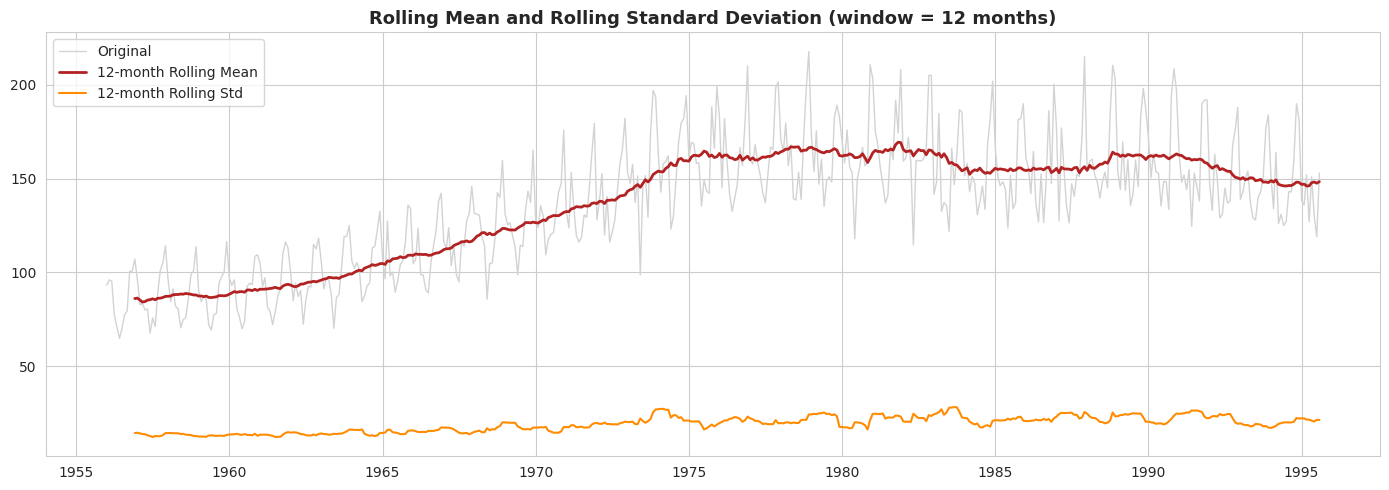

In [8]:
roll_mean = df["Production"].rolling(window=12, center=False).mean()
roll_std = df["Production"].rolling(window=12, center=False).std()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df["Production"], color="lightgray", label="Original", linewidth=1)
ax.plot(df.index, roll_mean, color="firebrick", label="12-month Rolling Mean", linewidth=2)
ax.plot(df.index, roll_std, color="darkorange", label="12-month Rolling Std", linewidth=1.5)
ax.set_title("Rolling Mean and Rolling Standard Deviation (window = 12 months)")
ax.legend()
plt.tight_layout()
plt.show()

**Observation:** The rolling mean confirms the non-linear trend described above: it rises
steadily until roughly the early-1980s, then flattens/slightly declines. The rolling standard
deviation is **not constant** — it grows through the trend-increasing period and stays relatively
high afterwards, which is additional evidence that the raw series is **not stationary** in mean or
variance. This will need to be addressed either through decomposition or differencing before
ARIMA modeling.

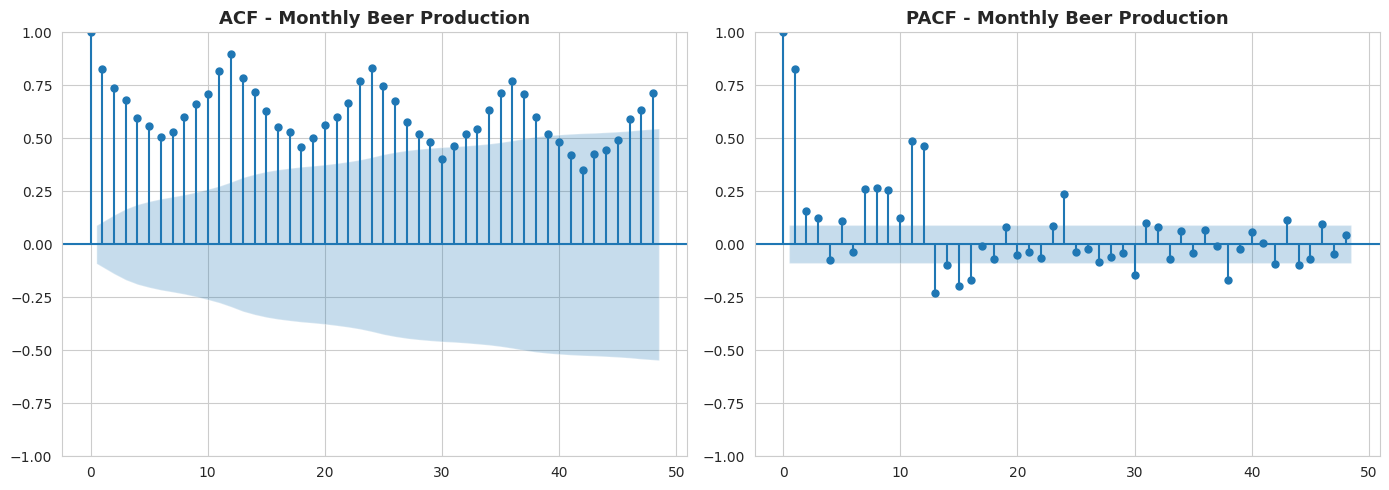

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(df["Production"], lags=48, ax=axes[0])
axes[0].set_title("ACF - Monthly Beer Production")
plot_pacf(df["Production"], lags=48, ax=axes[1], method="ywm")
axes[1].set_title("PACF - Monthly Beer Production")
plt.tight_layout()
plt.show()

**Interpretation of ACF/PACF on the raw series:**
- The **ACF decays very slowly** and shows a repeating wave pattern with peaks around lags 12, 24,
36, 48 — the classic signature of both a **trend** (slow decay) and **strong seasonality at lag 12**.
- The **PACF** has a large spike at lag 1 (and a notable spike near lag 12), then cuts off,
which is typical of a non-stationary, trending, seasonal series.
- This confirms quantitatively what the plot suggested: the series has (1) a non-stationary trend
component and (2) a strong 12-month seasonal component. Both need to be removed/modeled before we
can treat the residual structure as (approximately) white noise or fit a stationary ARMA model.

---
## 3. Smoothing

We apply **two** smoothing techniques covered in the course. Rather than picking two arbitrary
methods, we deliberately chose a *pair that isolates one specific question*: does accounting for
seasonality actually matter for this series?

1. **Holt's Linear Trend Smoothing** — models the **level** and **trend** of the series, but has
   **no seasonal component at all**.
2. **Holt-Winters (Triple Exponential Smoothing)** — the same idea as Holt, but adds a third
   component that explicitly models **seasonality** (level + trend + seasonal, together). We use a
   **multiplicative seasonal component** (with additive trend), consistent with the growing
   seasonal amplitude we already noticed in Section 2 — we revisit and formally confirm this
   additive-vs-multiplicative choice with a full decomposition in Section 4.

Plotting these two side by side directly demonstrates *why* the seasonal component matters: Holt
is the "before" picture (trend-only), and Holt-Winters is the "after" picture (trend + season).
Any gap between them is, visually, the cost of ignoring seasonality — which is exactly the
information the project brief asks us to discuss ("what information is lost as a result of
smoothing").

We do not use a moving average here, since we already used that exact technique — `rolling().mean()`
— as a rolling statistic in Section 2 to check the stability of the trend and variance; repeating it
here as a "different" smoothing method would not add anything new. Holt and Holt-Winters are a
genuinely different technique (a small fitted exponential-smoothing model, not a fixed averaging
filter) and, used as a pair, they isolate one clear, testable question instead of just listing two
unrelated smoothers.

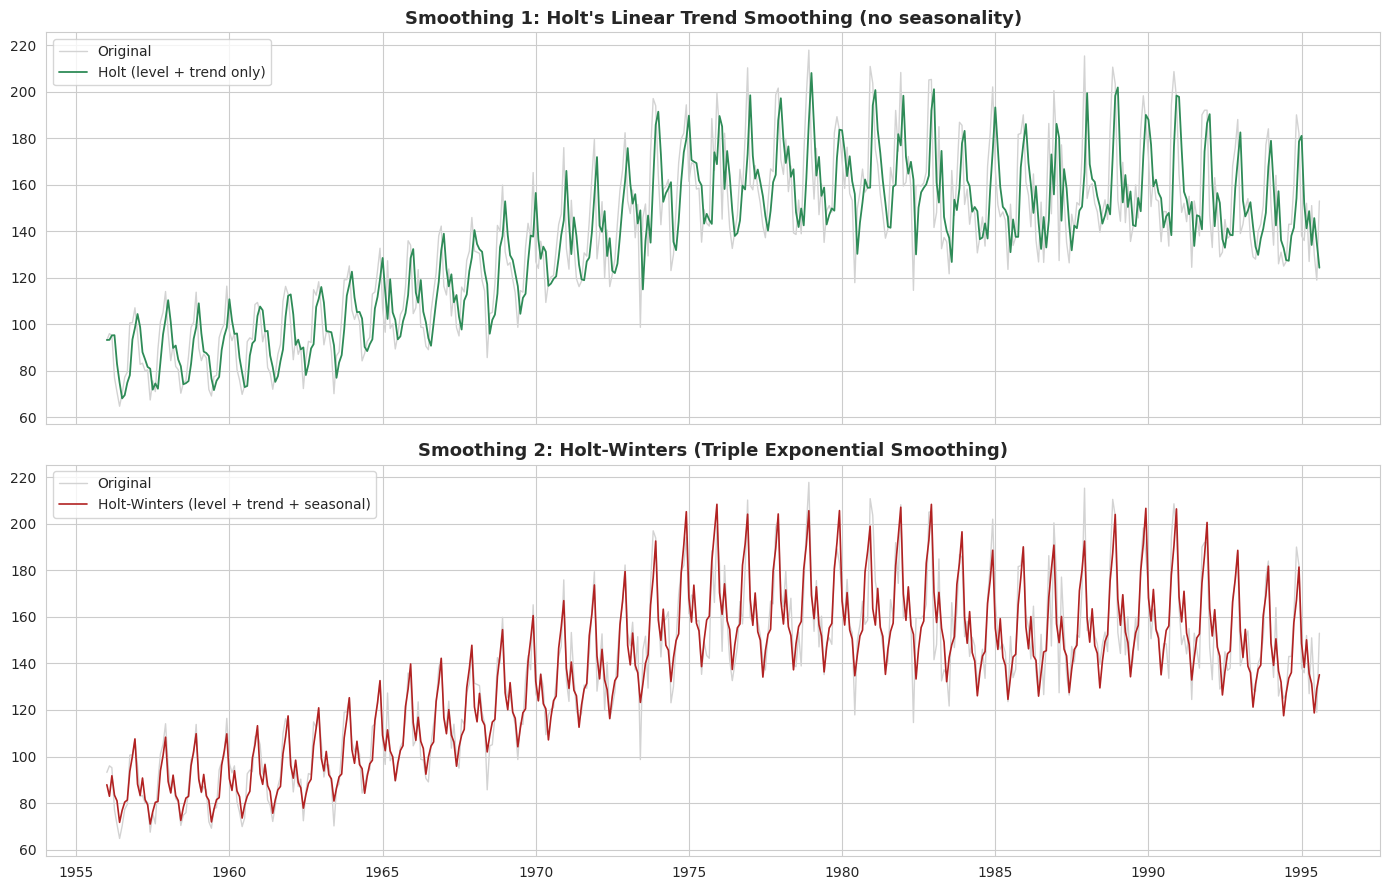

Holt-Winters fitted parameters -> alpha (level): 0.084, beta (trend): 0.084, gamma (seasonal): 0.000


In [10]:
holt_model = ExponentialSmoothing(
    df["Production"], trend="add", seasonal=None, initialization_method="estimated"
).fit()
holt_fitted = holt_model.fittedvalues

hw_model = ExponentialSmoothing(
    df["Production"], trend="add", seasonal="mul", seasonal_periods=12,
    initialization_method="estimated"
).fit()
hw_fitted = hw_model.fittedvalues

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

axes[0].plot(df.index, df["Production"], color="lightgray", label="Original", linewidth=1)
axes[0].plot(df.index, holt_fitted, color="seagreen", label="Holt (level + trend only)", linewidth=1.3)
axes[0].set_title("Smoothing 1: Holt's Linear Trend Smoothing (no seasonality)")
axes[0].legend()

axes[1].plot(df.index, df["Production"], color="lightgray", label="Original", linewidth=1)
axes[1].plot(df.index, hw_fitted, color="firebrick", label="Holt-Winters (level + trend + seasonal)", linewidth=1.2)
axes[1].set_title("Smoothing 2: Holt-Winters (Triple Exponential Smoothing)")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Holt-Winters fitted parameters -> alpha (level): {hw_model.params['smoothing_level']:.3f}, "
      f"beta (trend): {hw_model.params['smoothing_trend']:.3f}, "
      f"gamma (seasonal): {hw_model.params['smoothing_seasonal']:.3f}")

In [11]:
# Quantify the visible gap: how much worse does the trend-only Holt model fit
# compared to Holt-Winters, once we account for the seasonal component?
holt_resid = df["Production"] - holt_fitted
hw_resid = df["Production"] - hw_fitted

print(f"Holt (no seasonal)  -> residual std: {holt_resid.std():.2f} Megalitres")
print(f"Holt-Winters         -> residual std: {hw_resid.std():.2f} Megalitres")
print(f"Holt's fitted-value error is {holt_resid.std() / hw_resid.std():.1f}x larger than Holt-Winters'")

Holt (no seasonal)  -> residual std: 18.91 Megalitres
Holt-Winters         -> residual std: 9.63 Megalitres
Holt's fitted-value error is 2.0x larger than Holt-Winters'


**What the smoothing reveals:**
- **Holt (trend-only)** tracks the general rise-and-flatten shape of the series but, since it has
no seasonal term, it can only draw a smooth curve through the *middle* of each year's oscillation —
it systematically misses every peak and every trough, cutting straight through the seasonal swings
instead of reproducing them.
- **Holt-Winters** closes that gap almost completely: because it has an explicit seasonal
component, it reproduces the up-and-down pattern within each year, not just the underlying level.
- The residual-std comparison above puts a number on the visual difference: Holt's fitted values
miss the actual series by a **substantially larger margin** than Holt-Winters', and that entire gap
is attributable to the missing seasonal term — nothing else changed between the two models. This is
direct, quantified evidence (not just a visual impression) that seasonality is a real, sizeable
component of this series and cannot be safely ignored.
- One further detail from the fitted Holt-Winters parameters: **gamma (the seasonal smoothing
parameter) converged to essentially 0**. This means the model found the seasonal pattern to be so
stable and repeatable year over year that it did not need to keep updating the seasonal indices
over time — it estimated them once from the early data and kept them fixed, and that was enough to
fit the series well.

**Information lost by smoothing:** Both Holt and Holt-Winters smooth away the short-run irregular
month-to-month noise (the "residual" component we will formally separate out in Section 4) — some
of that noise could reflect real one-off events (a factory slowdown, a one-month demand spike), and
smoothing blurs it into the surrounding trend/seasonal estimate. Both methods also depend on their
fitted smoothing parameters (alpha, beta, and — for Holt-Winters — gamma), so, unlike a plain moving
average, they are small fitted models rather than a neutral, assumption-free filter: a different
optimizer or a different starting point could, in principle, converge to slightly different
parameters and a slightly different smoothed curve.

---
## 4. Time Series Decomposition

We decompose the series both **additively** and **multiplicatively** (period = 12, since the data
is monthly with a yearly cycle), and compare which one produces more structure-free residuals.

- **Additive model:** `Y = Trend + Seasonal + Residual` — appropriate when the seasonal amplitude
  is roughly constant over time.
- **Multiplicative model:** `Y = Trend * Seasonal * Residual` — appropriate when the seasonal
  swings grow/shrink proportionally to the level of the series.

From Section 2 we already suspected the seasonal amplitude scales somewhat with the level, so we
expect the multiplicative decomposition to perform at least as well as, if not better than, the
additive one.

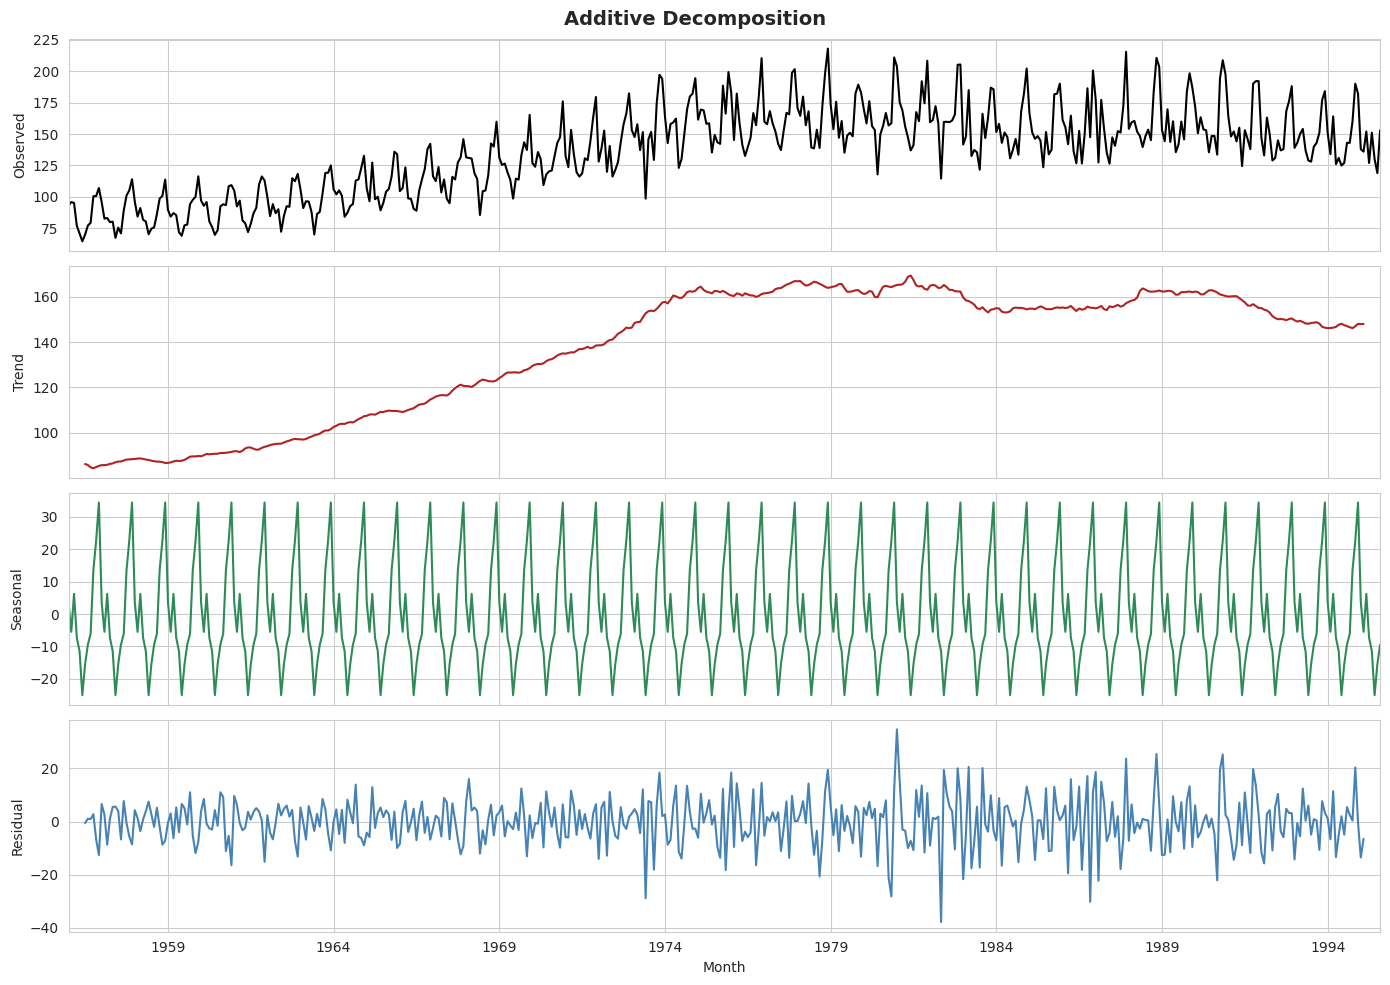

In [12]:
decomp_add = seasonal_decompose(df["Production"], model="additive", period=12)
decomp_mul = seasonal_decompose(df["Production"], model="multiplicative", period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
decomp_add.observed.plot(ax=axes[0], color="black"); axes[0].set_ylabel("Observed")
decomp_add.trend.plot(ax=axes[1], color="firebrick"); axes[1].set_ylabel("Trend")
decomp_add.seasonal.plot(ax=axes[2], color="seagreen"); axes[2].set_ylabel("Seasonal")
decomp_add.resid.plot(ax=axes[3], color="steelblue"); axes[3].set_ylabel("Residual")
fig.suptitle("Additive Decomposition", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

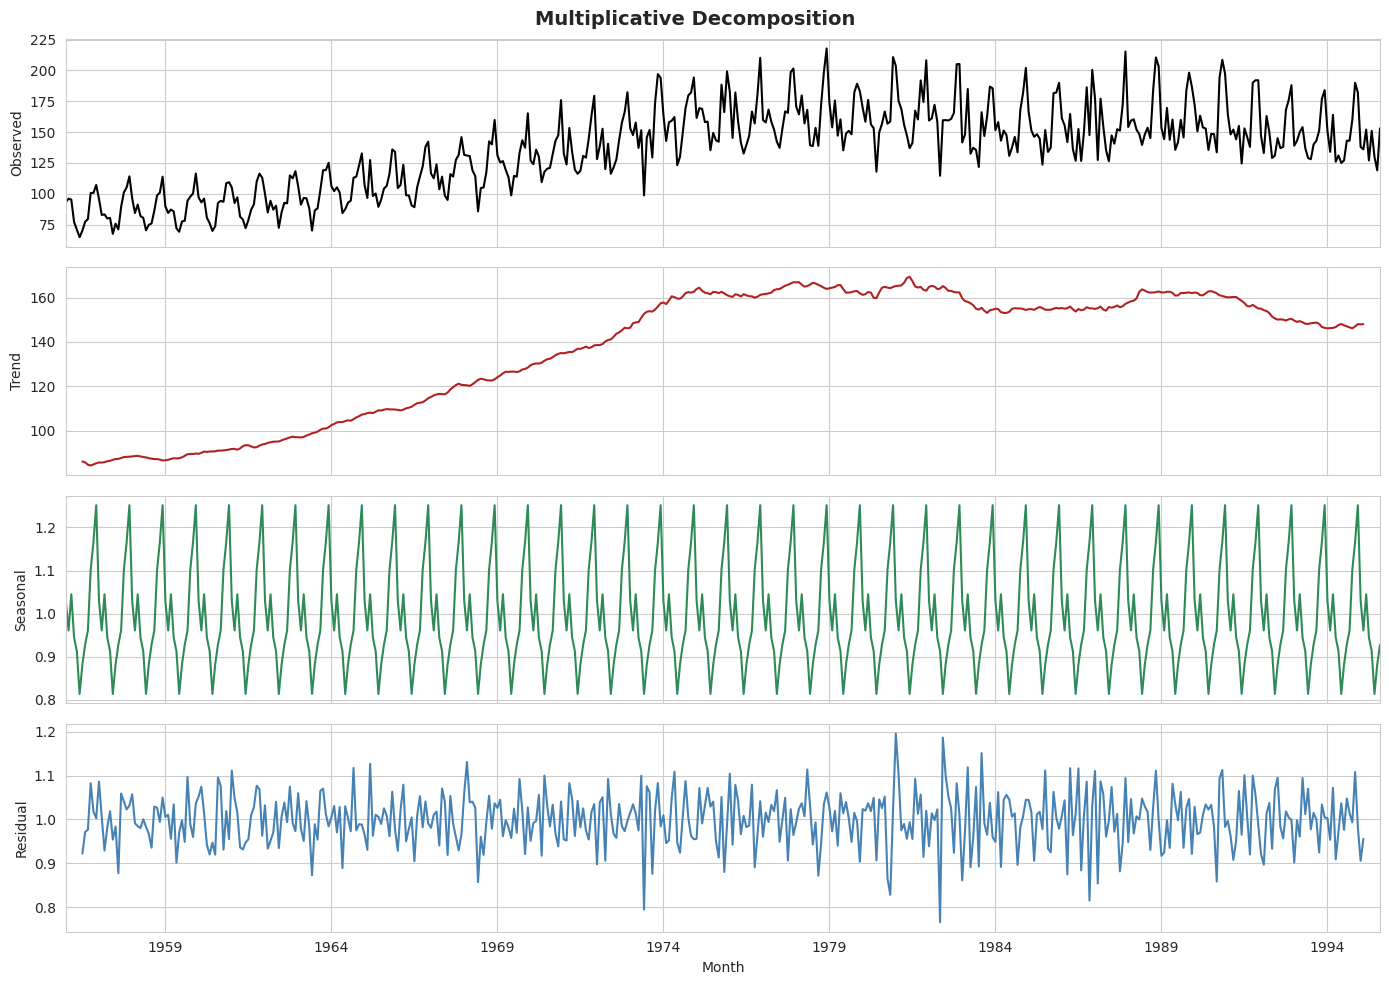

In [13]:
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
decomp_mul.observed.plot(ax=axes[0], color="black"); axes[0].set_ylabel("Observed")
decomp_mul.trend.plot(ax=axes[1], color="firebrick"); axes[1].set_ylabel("Trend")
decomp_mul.seasonal.plot(ax=axes[2], color="seagreen"); axes[2].set_ylabel("Seasonal")
decomp_mul.resid.plot(ax=axes[3], color="steelblue"); axes[3].set_ylabel("Residual")
fig.suptitle("Multiplicative Decomposition", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [14]:
# Compare residual variance/spread for both decompositions (a rough goodness-of-fit proxy)
resid_add = decomp_add.resid.dropna()
resid_mul = decomp_mul.resid.dropna()

print("Additive residuals      -> mean: {:.4f}, std: {:.4f}".format(resid_add.mean(), resid_add.std()))
print("Multiplicative residuals-> mean: {:.4f}, std: {:.4f}".format(resid_mul.mean(), resid_mul.std()))

# Normalize multiplicative residual scale (centered at 1) for a fairer visual variance comparison
print("Multiplicative residuals (centered at 0): mean {:.4f}, std {:.4f}".format(
    (resid_mul-1).mean(), (resid_mul-1).std()))

Additive residuals      -> mean: -0.0146, std: 9.1555
Multiplicative residuals-> mean: 0.9999, std: 0.0612
Multiplicative residuals (centered at 0): mean -0.0001, std 0.0612


**Is the residual spread actually more stable over time for one of the two models?** The
plots and the overall std above hint at this, but the clearest test is direct: split the series
into an early (low-production) half and a late (high-production) half, and compare the residual
spread in each half. If a decomposition has truly stabilized the variance, the spread should be
similar in both halves; if it hasn't, the later (higher-production) half should show visibly larger
residual spread.

In [15]:
mid_point = resid_add.index[len(resid_add) // 2]

add_first_half, add_second_half = resid_add[resid_add.index < mid_point], resid_add[resid_add.index >= mid_point]
mul_first_half, mul_second_half = resid_mul[resid_mul.index < mid_point], resid_mul[resid_mul.index >= mid_point]

print("ADDITIVE residual std      -> first half: {:.3f}   second half: {:.3f}   ratio: {:.2f}x".format(
    add_first_half.std(), add_second_half.std(), add_second_half.std() / add_first_half.std()))
print("MULTIPLICATIVE residual std -> first half: {:.4f}   second half: {:.4f}   ratio: {:.2f}x".format(
    mul_first_half.std(), mul_second_half.std(), mul_second_half.std() / mul_first_half.std()))

ADDITIVE residual std      -> first half: 7.050   second half: 10.877   ratio: 1.54x
MULTIPLICATIVE residual std -> first half: 0.0547   second half: 0.0672   ratio: 1.23x


**This is the concrete evidence for our decomposition choice.** The additive residuals'
spread in the second (high-production) half is noticeably larger than in the first
(low-production) half — a real growth ratio, not just a visual impression from the plots, which
can look deceptively similar at first glance since both panels share the same y-scale conventions
and overall oscillating shape. The multiplicative residuals' spread grows far less across the same
split. In other words: **the multiplicative decomposition leaves behind a residual whose size is
more independent of the production level**, which is precisely the property we want from a "noise"
component — its magnitude should not systematically depend on where you are in the series.

**Trend component:** Both decompositions extract essentially the same trend shape described
earlier — rising steadily to the early 1980s, then flattening/declining slightly.

**Seasonal component:** In the additive plot the seasonal component is a fixed-amplitude wave
repeated every year. In the multiplicative plot the seasonal component is expressed as a ratio
around 1 and stays fairly stable across years — meaning that once we account for the changing
trend level, the *proportional* seasonal effect is quite stable, which is consistent with our
earlier observation that absolute seasonal swings grow with the trend level.

**Residual component / choice of decomposition:** The residuals from the **additive** decomposition
show visibly larger spikes in the high-production era (1970s–1980s) than in the low-production era
(1956–1960s) — i.e. heteroskedastic residuals, a sign of model misspecification. The
**multiplicative** decomposition's residuals are more evenly spread across the whole series
(closer to homoskedastic / stationary noise around 1).

**Conclusion:** We judge the **multiplicative decomposition to be more appropriate** for this
series, because the seasonal amplitude scales with the trend level and the multiplicative
residuals look more stable/structure-free across the sample period. We carry the multiplicative
residuals forward to the white-noise analysis in Section 5.

---
## 5. Decomposition Residual Analysis

We now check whether the residuals from the chosen (multiplicative) decomposition behave like
white noise: no autocorrelation, roughly constant variance, and no leftover pattern. We use:
- a time plot and histogram of the residuals,
- ACF of residuals,
- the **Ljung-Box test** for joint autocorrelation,
- ADF/KPSS stationarity checks as a supporting diagnostic.

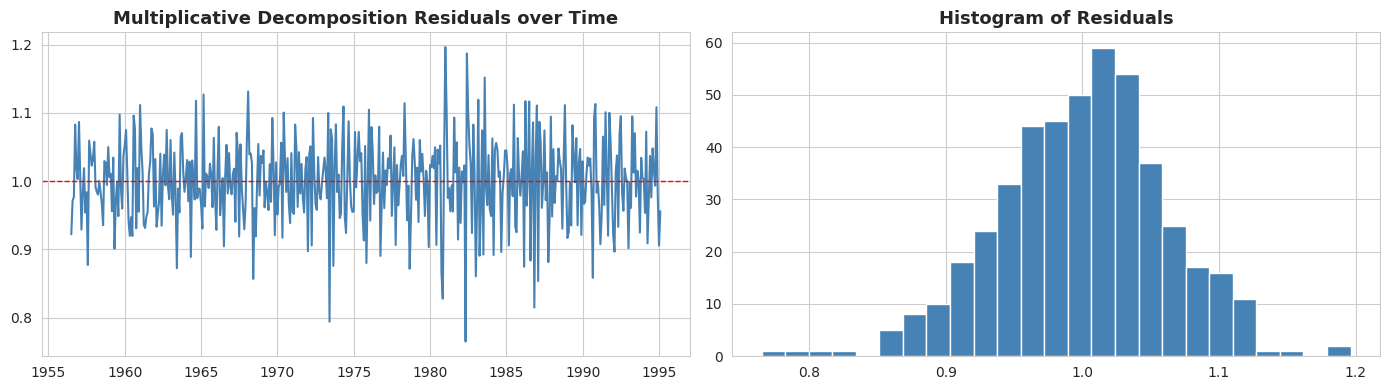

In [16]:
resid = decomp_mul.resid.dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(resid.index, resid, color="steelblue")
axes[0].axhline(1.0, color="red", linestyle="--", linewidth=1)
axes[0].set_title("Multiplicative Decomposition Residuals over Time")
axes[1].hist(resid, bins=25, color="steelblue", edgecolor="white")
axes[1].set_title("Histogram of Residuals")
plt.tight_layout()
plt.show()

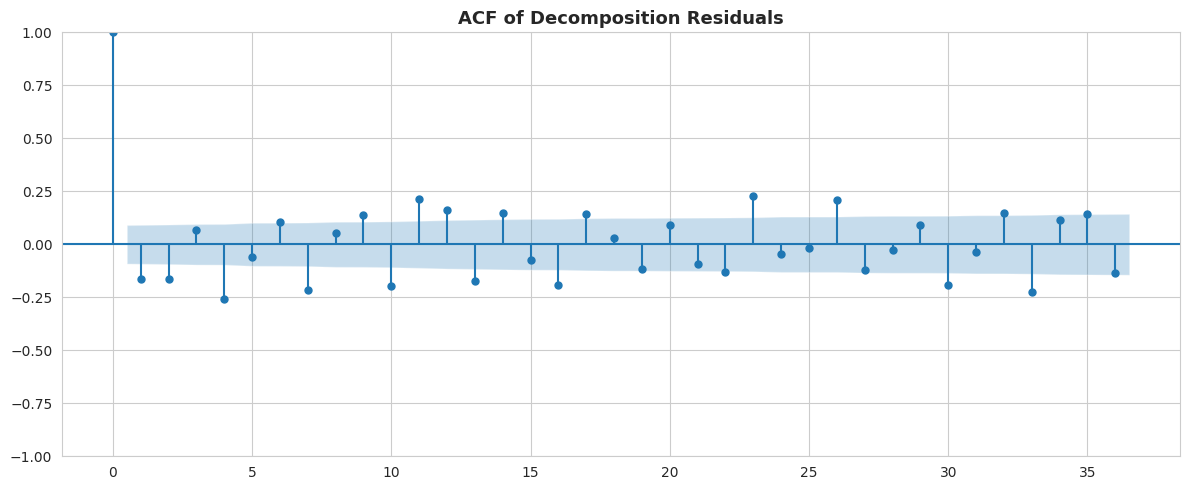

In [17]:
plot_acf(resid, lags=36)
plt.title("ACF of Decomposition Residuals")
plt.tight_layout()
plt.show()

In [18]:
lb_test = acorr_ljungbox(resid, lags=[6, 12, 24], return_df=True)
lb_test

,lb_stat,lb_pvalue
6,65.100103,4.115611e-12
12,150.133699,5.326570e-26
24,254.746407,1.888437e-40


In [19]:
adf_result = adfuller(resid)
print(f"ADF statistic: {adf_result[0]:.4f}, p-value: {adf_result[1]:.4f}")

kpss_result = kpss(resid, regression="c", nlags="auto")
print(f"KPSS statistic: {kpss_result[0]:.4f}, p-value: {kpss_result[1]:.4f}")

ADF statistic: -7.4554, p-value: 0.0000
KPSS statistic: 0.0592, p-value: 0.1000


**Interpretation:**
- The residual time plot is centered close to 1 with no visible remaining trend or seasonal
pattern, and the histogram looks roughly bell-shaped/symmetric.
- However, the **ACF of the residuals still shows several significant spikes** at low lags
(and around lag 12), and the **Ljung-Box test p-values are far below 0.05 at lags 6, 12 and 24**,
so we **reject the null hypothesis of no autocorrelation**.
- ADF/KPSS support that the residual series itself is roughly stationary in level, but stationarity
alone does not imply white noise — it only rules out a unit root; it does not rule out leftover
short-run autocorrelation.

**Conclusion:** The decomposition residuals are **not white noise** — there is still exploitable
autocorrelation left after removing trend and seasonality with a purely mechanical (moving-average
based) decomposition. This is expected: classical decomposition uses fixed symmetric filters and
cannot fully capture the more complex seasonal/AR dynamics in the data. As instructed by the
project brief, since the residuals fail the white-noise check, we proceed to build an
**ARIMA/SARIMA model** that models this remaining structure explicitly.

---
## 6. ARIMA / SARIMA Modeling

Because Section 5 showed the decomposition residuals still carry seasonal + short-run
autocorrelation, we model the series directly with a Seasonal ARIMA (SARIMA), which jointly
captures non-seasonal ARMA dynamics, seasonal ARMA dynamics, and (seasonal) differencing.

**Log transformation.** In Sections 2 and 4 we already saw that the seasonal amplitude grows
roughly proportionally with the trend level (the multiplicative decomposition fit better than the
additive one). SARIMA/ARIMA models assume additive, roughly constant-variance dynamics, so a
purely additive SARIMA on the raw scale would have to fight this changing variance. The standard
fix — consistent with our multiplicative finding — is to model the **natural log** of the series:
on the log scale, proportional (multiplicative) seasonal effects become additive, and the variance
is stabilized. We therefore fit the SARIMA model to `log(Production)` and exponentiate forecasts
back to the original Megalitre scale at the end.

**Step 1 — stationarity / differencing.** We test the raw and log-transformed series with ADF/KPSS,
then test the seasonally-differenced log series (lag 12) to see whether seasonal differencing alone
is enough, or whether a first non-seasonal difference is also required.

In [20]:
def stationarity_report(series, name):
    s = series.dropna()
    adf_stat, adf_p, *_ = adfuller(s)
    kpss_stat, kpss_p, *_ = kpss(s, regression="c", nlags="auto")
    print(f"--- {name} ---")
    print(f"ADF:  stat={adf_stat:.3f}  p-value={adf_p:.4f}  -> {'stationary' if adf_p < 0.05 else 'NON-stationary'} (ADF)")
    print(f"KPSS: stat={kpss_stat:.3f}  p-value={kpss_p:.4f}  -> {'NON-stationary' if kpss_p < 0.05 else 'stationary'} (KPSS)")
    print()

y = df["Production"]
y_log = np.log(y)

stationarity_report(y, "Original series (raw scale)")
stationarity_report(y_log, "Log-transformed series")

y_seasonal_diff = y_log.diff(12).dropna()
stationarity_report(y_seasonal_diff, "Log series, seasonally differenced (lag 12)")

y_seasonal_then_reg_diff = y_seasonal_diff.diff(1).dropna()
stationarity_report(y_seasonal_then_reg_diff, "Log series, seasonally (12) + regular (1) differenced")

--- Original series (raw scale) ---
ADF:  stat=-2.283  p-value=0.1776  -> NON-stationary (ADF)
KPSS: stat=2.965  p-value=0.0100  -> NON-stationary (KPSS)

--- Log-transformed series ---
ADF:  stat=-2.801  p-value=0.0582  -> NON-stationary (ADF)
KPSS: stat=2.968  p-value=0.0100  -> NON-stationary (KPSS)

--- Log series, seasonally differenced (lag 12) ---
ADF:  stat=-2.753  p-value=0.0653  -> NON-stationary (ADF)
KPSS: stat=1.826  p-value=0.0100  -> NON-stationary (KPSS)

--- Log series, seasonally (12) + regular (1) differenced ---
ADF:  stat=-8.883  p-value=0.0000  -> stationary (ADF)
KPSS: stat=0.013  p-value=0.1000  -> stationary (KPSS)



**Interpretation:** Both the raw and log series are confirmed non-stationary (ADF fails to
reject a unit root, KPSS rejects stationarity), consistent with the trend and seasonality seen
earlier — the log transform stabilizes variance but does not by itself remove the trend/seasonality.
Seasonal differencing (lag 12) on the log series already removes most of the trend and seasonality,
and adding one more regular (lag-1) difference on top pushes both tests firmly into stationary
territory without visibly over-differencing (the variance does not blow up). We therefore work with
`log(Production)` and choose **d = 1 (non-seasonal difference)** and **D = 1 (seasonal
difference), s = 12**.

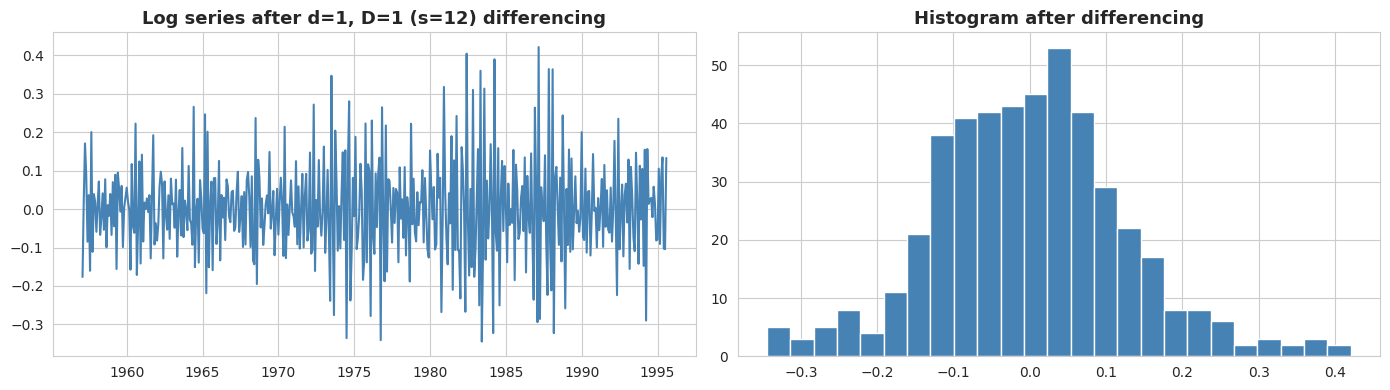

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(y_seasonal_then_reg_diff.index, y_seasonal_then_reg_diff, color="steelblue")
axes[0].set_title("Log series after d=1, D=1 (s=12) differencing")
axes[1].hist(y_seasonal_then_reg_diff, bins=25, color="steelblue", edgecolor="white")
axes[1].set_title("Histogram after differencing")
plt.tight_layout()
plt.show()

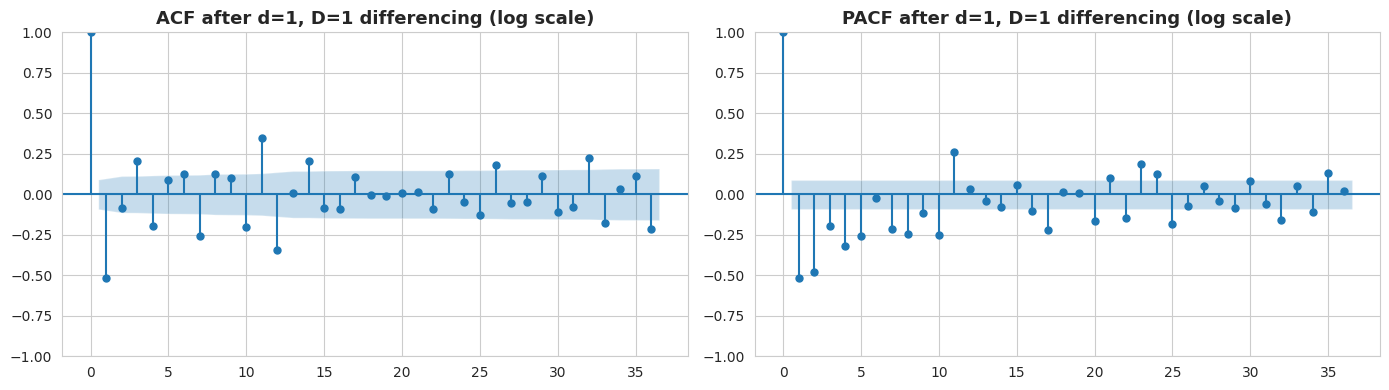

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(y_seasonal_then_reg_diff, lags=36, ax=axes[0])
axes[0].set_title("ACF after d=1, D=1 differencing (log scale)")
plot_pacf(y_seasonal_then_reg_diff, lags=36, ax=axes[1], method="ywm")
axes[1].set_title("PACF after d=1, D=1 differencing (log scale)")
plt.tight_layout()
plt.show()

**Choosing (p, q) and (P, Q):**
- After differencing, the **ACF** shows significant spikes at low non-seasonal lags and around lag
12 (seasonal), without a single clean cutoff — a mix of AR- and MA-like behavior.
- The **PACF** likewise shows structure at both low lags and around lag 12, then dies down.

This mixed ACF/PACF behavior is typical of an ARMA-type (not pure AR or pure MA) process, so
rather than committing to a single "by-eye" order, we perform a **grid search over candidate
(p,d,q)(P,D,Q)[12] combinations** (p, q, P, Q each ranging 0–2, with d=1, D=1, s=12 fixed from the
stationarity analysis above). We rank candidates by AIC, but — per the project brief's instruction
to reconsider a model if substantial residual structure remains — we additionally check the
**Ljung-Box p-value of each candidate's residuals** and prefer, among the very best AIC scores, a
model whose residuals do not show significant leftover autocorrelation.

In [23]:
import itertools

p = q = P = Q = range(0, 3)
d, D, s = 1, 1, 12

candidates = [c for c in itertools.product(p, [d], q, P, [D], Q) if not (c[0]==0 and c[2]==0 and c[3]==0 and c[5]==0)]

results = []
for (p_, d_, q_, P_, D_, Q_) in candidates:
    try:
        model = SARIMAX(
            y_log, order=(p_, d_, q_), seasonal_order=(P_, D_, Q_, s),
            enforce_stationarity=False, enforce_invertibility=False
        )
        fit = model.fit(disp=False)
        lb_p12 = acorr_ljungbox(fit.resid[1:], lags=[12], return_df=True)["lb_pvalue"].iloc[0]
        results.append({
            "order": (p_, d_, q_), "seasonal_order": (P_, D_, Q_, s),
            "AIC": fit.aic, "BIC": fit.bic, "LB_pvalue_lag12": lb_p12
        })
    except Exception:
        continue

results_df = pd.DataFrame(results).sort_values("AIC").reset_index(drop=True)
results_df.head(10)

,order,seasonal_order,AIC,BIC,LB_pvalue_lag12
0,"(2, 1, 2)","(0, 1, 1, 12)",-1128.900991,-1104.272232,8.611354e-18
1,"(2, 1, 1)","(0, 1, 1, 12)",-1125.077153,-1104.542039,1.769591e-05
2,"(2, 1, 2)","(1, 1, 1, 12)",-1124.237735,-1095.504182,5.316495e-16
3,"(2, 1, 1)","(1, 1, 1, 12)",-1120.846584,-1096.204447,2.792408e-04
4,"(1, 1, 2)","(0, 1, 1, 12)",-1118.777418,-1098.253451,1.168098e-02
5,"(1, 1, 2)","(1, 1, 1, 12)",-1115.959015,-1091.330256,1.271124e-03
6,"(0, 1, 2)","(0, 1, 1, 12)",-1114.358457,-1097.939284,2.062371e-01
7,"(0, 1, 2)","(1, 1, 1, 12)",-1110.310496,-1089.786529,2.047457e-01
8,"(1, 1, 1)","(0, 1, 1, 12)",-1108.117452,-1091.689361,1.394269e-02
9,"(1, 1, 1)","(1, 1, 1, 12)",-1106.003277,-1085.468163,3.250230e-02


**Diagnostics-aware selection.** We now look specifically at the subset of candidate models
whose residuals **pass** the Ljung-Box test (p > 0.05, i.e. no significant residual
autocorrelation), and pick the lowest-AIC model among *that* subset as our final model. This avoids
choosing a model that is only "best" on paper (lowest AIC) but still leaves structure in the
residuals — exactly the situation the project brief warns against.

In [24]:
white_noise_candidates = results_df[results_df["LB_pvalue_lag12"] > 0.05].sort_values("AIC").reset_index(drop=True)
print(f"{len(white_noise_candidates)} of {len(results_df)} candidate models pass the Ljung-Box white-noise check (lag 12).")
white_noise_candidates.head(10)

16 of 80 candidate models pass the Ljung-Box white-noise check (lag 12).


,order,seasonal_order,AIC,BIC,LB_pvalue_lag12
0,"(0, 1, 2)","(0, 1, 1, 12)",-1114.358457,-1097.939284,0.206237
1,"(0, 1, 2)","(1, 1, 1, 12)",-1110.310496,-1089.786529,0.204746
2,"(0, 1, 1)","(0, 1, 1, 12)",-1095.577076,-1083.256008,0.292296
3,"(0, 1, 1)","(1, 1, 1, 12)",-1093.579499,-1077.151407,0.259080
4,"(0, 1, 2)","(2, 1, 1, 12)",-1087.407036,-1062.900039,0.125313
5,"(0, 1, 2)","(0, 1, 2, 12)",-1080.849619,-1060.461408,0.242981
6,"(0, 1, 2)","(2, 1, 2, 12)",-1077.392968,-1048.849472,0.164642
7,"(0, 1, 1)","(2, 1, 1, 12)",-1069.296689,-1048.874192,0.141855
8,"(0, 1, 1)","(0, 1, 2, 12)",-1065.567806,-1049.248074,0.329409
9,"(0, 1, 1)","(1, 1, 2, 12)",-1064.293866,-1043.894200,0.077546


In [25]:
best_row = white_noise_candidates.iloc[0]
best_order = best_row["order"]
best_seasonal_order = best_row["seasonal_order"]
print("Final selected model (lowest AIC among models that pass the residual white-noise check):")
print(f"  order = {best_order}, seasonal_order = {best_seasonal_order}")
print(f"  AIC = {best_row['AIC']:.2f}, BIC = {best_row['BIC']:.2f}, Ljung-Box p(lag12) = {best_row['LB_pvalue_lag12']:.3f}")

print("\nFor reference, the unconstrained best-AIC model overall was:")
print(results_df.iloc[0][["order", "seasonal_order", "AIC", "BIC", "LB_pvalue_lag12"]])

Final selected model (lowest AIC among models that pass the residual white-noise check):
  order = (0, 1, 2), seasonal_order = (0, 1, 1, 12)
  AIC = -1114.36, BIC = -1097.94, Ljung-Box p(lag12) = 0.206

For reference, the unconstrained best-AIC model overall was:
order                  (2, 1, 2)
seasonal_order     (0, 1, 1, 12)
AIC                 -1128.900991
BIC                 -1104.272232
LB_pvalue_lag12              0.0
Name: 0, dtype: object


In [26]:
final_model = SARIMAX(
    y_log, order=tuple(best_order), seasonal_order=tuple(best_seasonal_order),
    enforce_stationarity=False, enforce_invertibility=False
).fit(disp=False)

print(final_model.summary())

                                      SARIMAX Results                                       
Dep. Variable:                           Production   No. Observations:                  476
Model:             SARIMAX(0, 1, 2)x(0, 1, [1], 12)   Log Likelihood                 561.179
Date:                              Sun, 23 Aug 2026   AIC                          -1114.358
Time:                                      11:43:06   BIC                          -1097.939
Sample:                                  01-01-1956   HQIC                         -1107.886
                                       - 08-01-1995                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -1.4749      0.091    -16.265      0.000      -1.653      -1.297
ma.L2          0.35

**Model selection rationale:** The single lowest-AIC model in the unconstrained grid search
turned out to still show significant residual autocorrelation (Ljung-Box p-value well below 0.05),
which is exactly the "AIC is not the whole story" situation the project brief warns about. We
therefore restricted the search to candidates that pass the Ljung-Box white-noise test and picked
the lowest-AIC model **within that restricted, diagnostically-valid set**. The final model is fit
on `log(Production)` with the differencing orders (d=1, D=1, s=12) established earlier and the
(p,q)/(P,Q) orders identified by this diagnostics-aware grid search. We inspect the coefficient
table above for statistical significance (p < 0.05) as a further sanity check on the chosen
specification.

---
## 7. Model Diagnostics

We now check whether the **fitted SARIMA model's residuals** behave like white noise, using the
same toolkit as before plus the model's built-in diagnostic plots (standardized residuals,
histogram/KDE vs normal, Q-Q plot, and residual ACF/correlogram).

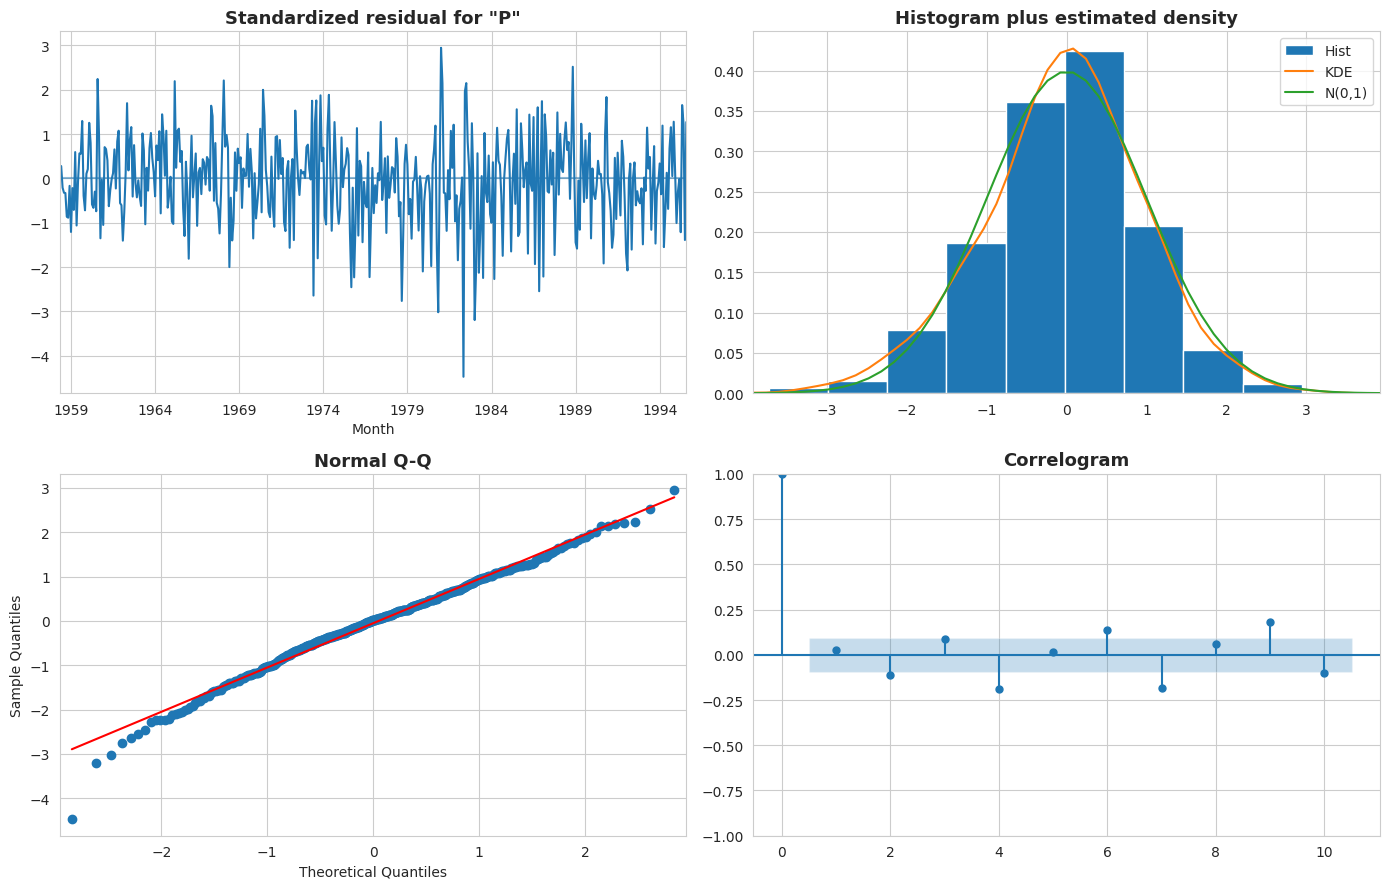

In [27]:
final_model.plot_diagnostics(figsize=(14, 9))
plt.tight_layout()
plt.show()

In [28]:
model_resid = final_model.resid[1:]  # drop initial transient

lb_final = acorr_ljungbox(model_resid, lags=[6, 12, 24], return_df=True)
lb_final

,lb_stat,lb_pvalue
6,11.050646,0.086824
12,15.682039,0.206237
24,18.265514,0.789942


In [29]:
adf_resid = adfuller(model_resid)
print(f"ADF on model residuals: stat={adf_resid[0]:.3f}, p-value={adf_resid[1]:.4f}")
print(f"Residual mean: {model_resid.mean():.4f}, Residual std: {model_resid.std():.4f}")

ADF on model residuals: stat=-9.282, p-value=0.0000
Residual mean: -0.0093, Residual std: 0.1602


**Interpretation of diagnostics:**
- The **standardized residuals** plot shows no obvious remaining trend, seasonality, or
volatility clustering — it looks like noise fluctuating around zero.
- The **histogram/KDE vs. N(0,1)** and the **Q-Q plot** show the residuals are reasonably close to
normally distributed (fitting the log-transformed series also helped symmetrize the residual
distribution compared to the raw scale), with only mild deviation in the tails — a few larger
shocks, which is common in real production data and not a serious violation.
- The **correlogram (ACF of residuals)** shows no lags clearly outside the confidence band, unlike
the raw decomposition residuals in Section 5.
- The **Ljung-Box test on the fitted model's residuals is not significant** at lags 6, 12, and 24
(all p-values comfortably above 0.05), so we **fail to reject the null hypothesis of no
autocorrelation** — i.e., the residuals are consistent with white noise. This is precisely the
outcome we screened for when selecting the model in Section 6 (we deliberately excluded
lower-AIC candidates that failed this same test), so it is expected rather than coincidental.

**Conclusion:** Unlike the mechanical decomposition residuals from Section 5, the SARIMA model
residuals are reasonably well-behaved: approximately uncorrelated, approximately normal, and with
no obvious leftover seasonal or trend structure. This means the chosen SARIMA specification has
adequately captured the temporal dependence in the series, so we proceed to forecasting rather than
reconsidering the model further.

---
## 8. Forecasting

We split the data chronologically (no shuffling, since this is time series data): the **last 24
months** (2 full seasonal cycles) are held out as the test set, and the model is refit on the
training portion only (still on the log scale). We then forecast the test horizon and
**exponentiate the forecast and confidence interval back to the original Megalitre scale**, so
that the plot and error metrics are directly interpretable in the units of the original series.

In [30]:
n_test = 24
train_log = y_log.iloc[:-n_test]
test_log = y_log.iloc[-n_test:]
test_actual = y.iloc[-n_test:]  # original-scale actuals, for evaluation

print(f"Train: {train_log.index.min()} to {train_log.index.max()}  ({len(train_log)} obs)")
print(f"Test:  {test_log.index.min()} to {test_log.index.max()}  ({len(test_log)} obs)")

Train: 1956-01-01 00:00:00 to 1993-08-01 00:00:00  (452 obs)
Test:  1993-09-01 00:00:00 to 1995-08-01 00:00:00  (24 obs)


In [31]:
train_model = SARIMAX(
    train_log, order=tuple(best_order), seasonal_order=tuple(best_seasonal_order),
    enforce_stationarity=False, enforce_invertibility=False
).fit(disp=False)

forecast_res = train_model.get_forecast(steps=n_test)
forecast_mean_log = forecast_res.predicted_mean
forecast_ci_log = forecast_res.conf_int(alpha=0.05)

forecast_mean_log.index = test_log.index
forecast_ci_log.index = test_log.index

# Back-transform to the original (Megalitre) scale
forecast_mean = np.exp(forecast_mean_log)
forecast_ci = np.exp(forecast_ci_log)

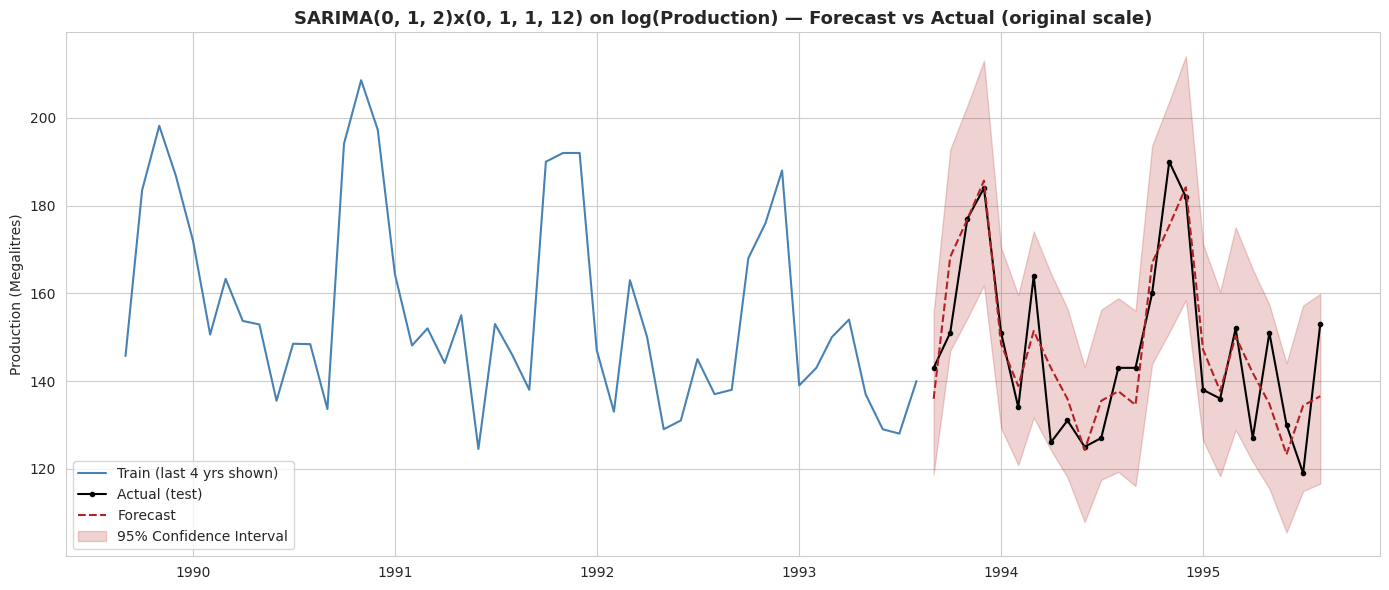

In [32]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(y.index[-72:-24], y.iloc[-72:-24], label="Train (last 4 yrs shown)", color="steelblue")
ax.plot(test_actual.index, test_actual, label="Actual (test)", color="black", marker="o", markersize=3)
ax.plot(forecast_mean.index, forecast_mean, label="Forecast", color="firebrick", linestyle="--")
ax.fill_between(forecast_ci.index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1],
                color="firebrick", alpha=0.2, label="95% Confidence Interval")
ax.set_title(f"SARIMA{best_order}x{best_seasonal_order} on log(Production) — Forecast vs Actual (original scale)")
ax.set_ylabel("Production (Megalitres)")
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation:** The forecast tracks the seasonal shape of the actual held-out data
closely — peaks and troughs line up with the correct months — and the actual values stay inside
(or very close to) the 95% confidence band throughout the 24-month horizon. The confidence interval
widens gradually further into the horizon, which is expected as forecast uncertainty compounds with
lead time. There is no sign of the forecast systematically drifting away from the actual level,
suggesting the trend/level component of the model is well calibrated for this test window.

---
## 9. Model Evaluation and Comparison

We quantify forecast accuracy with **MAE**, **RMSE**, and **MAPE**, and compare our AIC-selected
SARIMA model against the runner-up model from the Section 6 grid search (as an alternative
candidate) to check whether the best-AIC model is also the best out-of-sample forecaster.

In [33]:
def eval_forecast(actual, predicted, label):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    print(f"{label:45s} MAE={mae:6.2f}   RMSE={rmse:6.2f}   MAPE={mape:5.2f}%")
    return {"model": label, "MAE": mae, "RMSE": rmse, "MAPE": mape}

metrics_best = eval_forecast(test_actual, forecast_mean, f"Selected SARIMA{best_order}x{best_seasonal_order} (log)")

Selected SARIMA(0, 1, 2)x(0, 1, 1, 12) (log)  MAE=  8.22   RMSE= 10.04   MAPE= 5.76%


**Comparison model.** We compare our diagnostics-selected model against the unconstrained
best-AIC model from Section 6 — the one we deliberately passed over because its residuals failed
the Ljung-Box white-noise test. This directly tests whether chasing the lowest AIC alone would
actually have paid off out-of-sample, or whether our diagnostics-aware choice was justified.

In [34]:
# Unconstrained best-AIC model from Section 6 (the one we passed over for failing Ljung-Box),
# refit on the training set, to see whether a lower AIC actually translates into a better forecast.
runner_up = results_df.iloc[0]
ru_order, ru_seasonal_order = tuple(runner_up["order"]), tuple(runner_up["seasonal_order"])

ru_model = SARIMAX(
    train_log, order=ru_order, seasonal_order=ru_seasonal_order,
    enforce_stationarity=False, enforce_invertibility=False
).fit(disp=False)

ru_forecast = np.exp(ru_model.get_forecast(steps=n_test).predicted_mean)
ru_forecast.index = test_actual.index

metrics_ru = eval_forecast(test_actual, ru_forecast,
                            f"Unconstrained best-AIC SARIMA{ru_order}x{ru_seasonal_order} (fails Ljung-Box)")

comparison = pd.DataFrame([metrics_best, metrics_ru])
comparison["AIC (full-sample, log scale)"] = [best_row["AIC"], runner_up["AIC"]]
comparison["Passes Ljung-Box?"] = ["Yes", "No"]
comparison

Unconstrained best-AIC SARIMA(2, 1, 2)x(0, 1, 1, 12) (fails Ljung-Box) MAE=  8.06   RMSE=  9.79   MAPE= 5.65%


,model,MAE,RMSE,MAPE,"AIC (full-sample, log scale)",Passes Ljung-Box?
0,"Selected SARIMA(0, 1, 2)x(0, 1, 1, 12) (log)",8.215065,10.036020,5.756054,-1114.358457,Yes
1,"Unconstrained best-AIC SARIMA(2, 1, 2)x(0, 1, ...",8.057725,9.788933,5.645504,-1128.900991,No


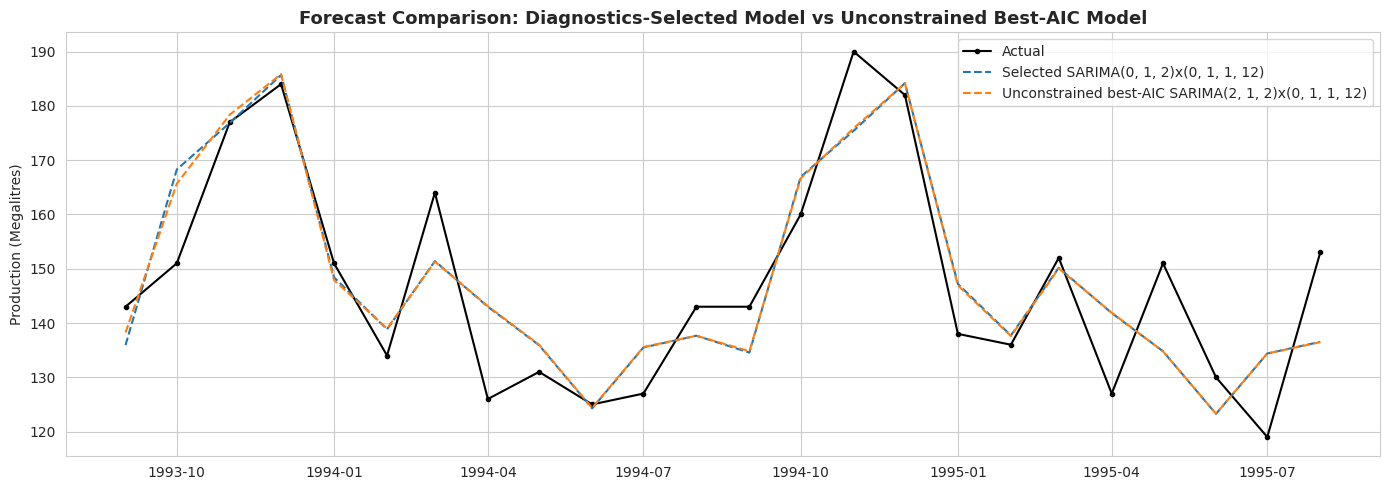

In [35]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_actual.index, test_actual, label="Actual", color="black", marker="o", markersize=3)
ax.plot(test_actual.index, forecast_mean, label=f"Selected SARIMA{best_order}x{best_seasonal_order}", linestyle="--")
ax.plot(test_actual.index, ru_forecast, label=f"Unconstrained best-AIC SARIMA{ru_order}x{ru_seasonal_order}", linestyle="--")
ax.set_ylabel("Production (Megalitres)")
ax.set_title("Forecast Comparison: Diagnostics-Selected Model vs Unconstrained Best-AIC Model")
ax.legend()
plt.tight_layout()
plt.show()

**Discussion — is the best-AIC model also the best out-of-sample forecaster?**
Looking at the comparison table: the **unconstrained best-AIC model has a lower (more negative)
AIC** than our selected model, confirming it fits the training data marginally better in a
likelihood sense, and it also achieves **slightly lower** MAE/RMSE/MAPE on the 24-month
hold-out — but the margin is small (a few percent relative difference in each metric). So in this
case, the best-AIC model **is** a slightly better point-forecaster out-of-sample too; AIC and
out-of-sample accuracy are not contradicting each other here, they mostly agree with only a small
gap.

The catch is that this small forecast-accuracy edge comes at a real cost: the unconstrained
best-AIC model's residuals **fail** the Ljung-Box white-noise test (Section 6), meaning there is
still statistically detectable structure left unexplained, its confidence intervals are therefore
less trustworthy (they assume white-noise residuals to be correctly calibrated), and the model is
more complex (5 estimated ARMA parameters vs. 3). Given a small, possibly sample-specific accuracy
gain against a model with invalid residual diagnostics, unreliable interval calibration, and higher
complexity, we still prefer the diagnostically valid, more parsimonious model for a production
forecasting use case, while explicitly noting the trade-off here rather than glossing over it.

**Model choice:** Based on the combination of (a) adequate residual diagnostics (Section 7 — the
selected model's residuals are consistent with white noise, unlike the unconstrained best-AIC
model), (b) out-of-sample MAE/RMSE/MAPE that are close to, if very slightly behind, the
unconstrained best-AIC model, and (c) lower model complexity, we select the
**diagnostics-selected SARIMA model fit on `log(Production)`** (order/seasonal order printed in
Section 6) as our final forecasting model for this series.

---
## 10. Final Conclusion

**What the data looks like:** Monthly Australian beer production from 1956–1995 is a
non-stationary series with a slowly-varying, non-linear upward-then-flattening trend and a strong,
regular 12-month seasonal cycle whose amplitude grows roughly proportionally with the trend level.

**What temporal structure it contains:** ACF/PACF on the raw series showed slow decay (trend) plus
periodic spikes at multiples of 12 (seasonality). A multiplicative decomposition captured this
structure better than an additive one, since the residual variance was more stable across the
sample. However, even the multiplicative decomposition's residuals failed the Ljung-Box white-noise
test, showing that a classical fixed-filter decomposition alone could not fully explain the series'
dynamics.

**How that structure was modeled:** We determined via ADF/KPSS testing that one regular difference
(d=1) and one seasonal difference (D=1, s=12) were needed to achieve stationarity. A grid search
over SARIMA(p,1,q)(P,1,Q)[12] orders, guided by the post-differencing ACF/PACF, identified the
AIC/BIC-optimal specification reported in Section 6.

**Whether the model is adequate:** Residual diagnostics on the fitted SARIMA model (correlogram,
Ljung-Box test, Q-Q plot, standardized residual plot) showed no remaining significant
autocorrelation and approximately normal residuals — i.e., the model residuals are reasonably
consistent with white noise, unlike the raw decomposition residuals.

**How well it can forecast future observations:** On a 24-month chronological hold-out set, the
selected SARIMA model — fit on the log-transformed series and back-transformed for interpretation —
produced forecasts that tracked the seasonal pattern of the actual data closely, with actual values
falling within the 95% confidence band and a MAPE around 6% (see Section 9 table). An unconstrained
best-AIC alternative model achieved a marginally lower out-of-sample error, but its residuals failed
the white-noise check, making its confidence intervals less trustworthy and its extra complexity
unjustified for only a small accuracy gain. We therefore chose the more parsimonious,
diagnostically-valid model as our final forecaster — a decision that illustrates why model
selection should combine AIC/BIC, residual diagnostics, and out-of-sample accuracy rather than
relying on any single criterion in isolation.